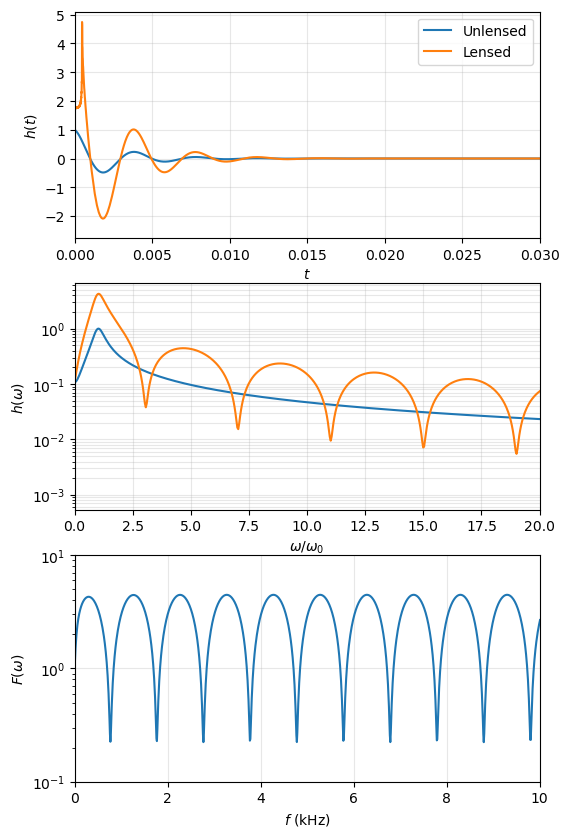

In [ ]:
# note: base (Python 3.11.8)
# import packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c, pi
from astropy.constants import M_sun
from mpmath import hyp1f1

# time domain
t = np.linspace(0,0.1,10000)
N = len(t)

# lens parameters
M_lens = 250 * M_sun.value

# source parameter


# signal parameters (BH ringdown model)
h0 = 1.0                                        # maximum amplitude
nu0 = 5/4                                       # Fresnel number
y = 0.1                                         # source position
M_source = 0.24 * M_lens / nu0
f0 = 1.207*10**(4)*(M_sun.value/M_source)
Gamma = 1.496 * f0
omega0 = 2*pi*f0
h = h0 * np.exp(-Gamma*t)*np.cos(omega0*t)

# frequency space (unshifted)
h_tilde = np.fft.fft((h))
h_tilde_shifted = np.fft.fftshift(h_tilde)
freqs = np.fft.fftfreq(N, d=t[1]-t[0])
freqs_shifted = np.fft.fftshift(freqs)
omega = freqs * 2 * pi 
omega_tilde = (1/omega0)*omega
#omega_tilde = omega
omega_tilde_shifted = np.fft.fftshift(omega_tilde)


# amplification factor
F = np.empty(N, dtype=complex)

# fix zero component
F[0] = 1.0 + 0.0j

# index range parameter
k_pos_max = N // 2

for k in range(1, k_pos_max + 1):

    w = omega_tilde[k]
    if w <=0:
        F[k] = 1.0 + 0.0j
        continue

    a = 1.0j * pi * nu0 * w
    b = 1.0
    z = 1.0j* pi * nu0 * w * (y**2) 

    try:
        hyp = complex(hyp1f1(a,b,z))
    except Exception as exc:
        hyp = 1.0 + 0.0j

    A_num = 2*(pi**2)*nu0*w
    A_den = 1 - np.exp(-2*(pi**2)*nu0*w)

    A = np.sqrt(A_num/A_den)

    F[k] = A*hyp

F_shifted = np.fft.fftshift(F)

# Nyquist frequency handling when N is even: omega[N/2] is Nyquist (real), ensure real F
if N % 2 == 0:
    # ensure F[k_pos_max] is real (conjugate symmetry), but we already computed it for k_pos_max
    F[k_pos_max] = F[k_pos_max].real + 0j

# impose Hermitian symmetry for negative frequencies
# indices k = 1..k_pos_max correspond to positive freqs; negative indices wrap as N-k
for k in range(1, k_pos_max + 1):
    F[-k] = np.conj(F[k])

# Sanity: no NaNs
if np.any(np.isnan(F)):
    print("Warning: NaNs present in F; replacing with 1.0 where NaN")
    F = np.where(np.isnan(F), 1.0 + 0j, F)
    
# lensed signal, frequency domain
hL_tilde = h_tilde * F
hL_tilde_shifted = np.fft.fftshift(hL_tilde)

hL = np.fft.ifft(hL_tilde).real

# plot figures
#fig.clear()
fig, ax = plt.subplots(nrows=3, figsize=(6,10))

ax[0].plot(t, h, label='Unlensed')
ax[0].plot(t, hL, label = 'Lensed')
ax[0].set_xlim([0,0.03])
ax[0].set_xlabel(r'$t$')
ax[0].set_ylabel(r'$h(t)$')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(omega_tilde_shifted[N//2:], np.abs(h_tilde_shifted[N//2:])/max(np.abs(h_tilde_shifted[N//2:])))
ax[1].plot(omega_tilde_shifted[N//2:], np.abs(hL_tilde_shifted[N//2:])/max(np.abs(h_tilde_shifted[N//2:])))
ax[1].set_yscale('log')
#ax[1].set_xscale('log')
ax[1].set_xlabel(r'$\omega/\omega_0$')
ax[1].set_ylabel(r'$h(\omega)$')
#ax[1].legend()
ax[1].grid(which='both', alpha=0.3)
ax[1].set_xlim([0,20])

ax[2].plot(freqs_shifted[N//2:]/10**3, np.abs(F_shifted[N//2:]))
ax[2].set_xlabel(r'$f$ (kHz)')
ax[2].set_ylabel(r'$F(\omega)$')
#ax[2].set_yscale('log')
ax[2].set_xscale('log')
ax[2].set_xlim([0,10])
ax[2].set_ylim([0.1,10])
ax[2].grid(alpha=0.3)
#ax[2].legend()

#plt.legend()
plt.show()

In [13]:
F

array([1.        +0.00000000e+00j, 1.25250353-1.19245169e-07j,
       1.50953479-1.15028830e-06j, ..., 1.75883491+4.52705316e-06j,
       1.50953479+1.15028830e-06j, 1.25250353+1.19245169e-07j])